# Task 4 — Text Chunking

Splits the cleaned paper text into retrieval-sized chunks for the ChromaDB knowledge base (Task 5). The implementation lives in `src/cleaning.py` and `src/chunking.py` (with tests in `tests/`); this notebook runs it on the full dataset and verifies the results.

Key design points:
- **Token-aware sizing** — chunk sizes are measured with the embedding model's own tokenizer (`BAAI/bge-small-en-v1.5`, 512-token limit), because that model silently truncates anything longer at embedding time. The 512 budget *includes* the `[CLS]`/`[SEP]` special tokens the model adds, so the content budget per chunk is 510 — encoded chunks genuinely fit.
- **Recursive splitting** (LangChain `RecursiveCharacterTextSplitter`) — 2026 benchmarks on academic papers favor this over semantic chunking, which fragments papers and runs ~14× slower.
- **Citations preserved** — every chunk carries paper id, title, and page range in flat metadata, ready for ChromaDB and the November retrieval-accuracy evaluation.
- **Swappable input** — chunking consumes cleaned page records; when Task 3's preprocessing lands, it replaces the interim cleaner in `src/cleaning.py` with no changes here.

In [1]:
import sys
sys.path.insert(0, "..")

from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error()  # token-count warnings are expected when measuring full pages

import pandas as pd
import matplotlib.pyplot as plt

from src.data_io import load_pages
from src.cleaning import clean_pages
from src.chunking import ChunkingConfig, build_chunks, chunk_stats

pages = load_pages()
cleaned = clean_pages(pages)
print(f"{len(pages)} pages loaded and cleaned")

[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


218 pages loaded and cleaned


## Cleaning: before vs after

A sample showing the artifact fixes (ligatures, hyphenated line-wraps, control characters).

In [2]:
import re

# find a page with a ligature and a hyphen wrap to show the fix
sample = next(p for p in pages if "\ufb01" in p["text"] and re.search(r"[a-z]-\n[a-z]", p["text"]))
clean_sample = next(c for c in cleaned if c["paper_id"] == sample["paper_id"] and c["page_number"] == sample["page_number"])

i = sample["text"].index("\ufb01")
print("BEFORE:", repr(sample["text"][i-60:i+60]))
j = re.search(r"[a-z]-\n[a-z]", sample["text"]).start()
print("BEFORE:", repr(sample["text"][j-50:j+50]))
print()
print("AFTER :", repr(clean_sample["text"][i-60:i+60]))

BEFORE: 'their parameters, and achieve state-of-the-art results when ﬁne-tuned on down-\nstream NLP tasks. However, their ability '
BEFORE: 'eve state-of-the-art results when ﬁne-tuned on down-\nstream NLP tasks. However, their ability to acc'

AFTER : 'their parameters, and achieve state-of-the-art results when fine-tuned on downstream NLP tasks. However, their ability t'


## Chunk the full corpus (default config: 512 tokens, 64 overlap, page scope)

In [3]:
config = ChunkingConfig()
chunks = build_chunks(cleaned, config)
chunk_stats(chunks)

{'n_chunks': 554,
 'n_papers': 10,
 'tokens_min': 46,
 'tokens_mean': 404.4,
 'tokens_max': 510,
 'under_100_tokens': 27}

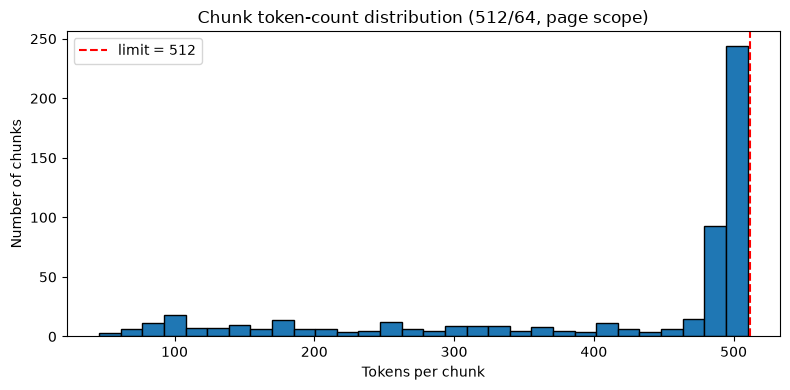

In [4]:
token_counts = [c["metadata"]["token_count"] for c in chunks]
plt.figure(figsize=(8, 4))
plt.hist(token_counts, bins=30, edgecolor="black")
plt.axvline(config.chunk_size, color="red", linestyle="--", label=f"limit = {config.chunk_size}")
plt.xlabel("Tokens per chunk")
plt.ylabel("Number of chunks")
plt.title("Chunk token-count distribution (512/64, page scope)")
plt.legend()
plt.tight_layout()
plt.show()

## Experiment: chunk size × overlap × scope

The parameters Task 5's retrieval evaluation will choose between. `page` scope keeps every chunk on one page (unambiguous citations); `paper` scope joins pages first so sentences spanning page breaks stay intact, and chunks cite a page range.

In [5]:
rows = []
for scope in ("page", "paper"):
    for size in (256, 384, 512):
        for overlap in (0, 64):
            cfg = ChunkingConfig(chunk_size=size, chunk_overlap=overlap, scope=scope)
            stats = chunk_stats(build_chunks(cleaned, cfg))
            rows.append({"scope": scope, "chunk_size": size, "overlap": overlap, **stats})
pd.DataFrame(rows).drop(columns=["n_papers"])

,scope,chunk_size,overlap,n_chunks,tokens_min,tokens_mean,tokens_max,under_100_tokens
0,page,256,0,964,1,214.6,254,91
1,page,256,64,1125,6,225.8,254,45
2,page,384,0,664,6,311.6,382,48
3,page,384,64,715,6,324.6,382,32
4,page,512,0,518,8,399.4,510,39
5,page,512,64,554,46,404.4,510,27
6,paper,256,0,867,6,238.6,254,12
7,paper,256,64,1098,6,240.3,254,9
8,paper,384,0,575,6,359.8,382,11
9,paper,384,64,664,6,362.3,382,9


## Sample chunks: is technical context retained?

The **same passage** under both configurations — selected by anchoring on a fixed sentence from the LoRA paper, so the comparison really shows the same content chunked small vs large. Checking that a chunk read on its own still carries enough context to be useful to the generator.

In [6]:
ANCHOR = "A pre-trained model can be shared"  # fixed sentence in the LoRA paper

def show_anchored_chunk(chunks_list, anchor):
    c = next(c for c in chunks_list if anchor in c["text"])
    m = c["metadata"]
    print(f"--- {c['chunk_id']} | pages {m['page_start']}-{m['page_end']} | {m['token_count']} tokens ---")
    print(c["text"])
    print()

small = build_chunks(cleaned, ChunkingConfig(chunk_size=256, chunk_overlap=32))
print("================ the passage in a 256-token chunk ================")
show_anchored_chunk(small, ANCHOR)
print("================ the same passage in a 512-token chunk ================")
show_anchored_chunk(chunks, ANCHOR)

================ the passage in a 256-token chunk ================
--- 2106.09685_a1f98a1b_c0005 | pages 2-2 | 248 tokens ---
adaptation instead, while keeping the pre-trained weights frozen, as shown in Figure 1. Using GPT-3
175B as an example, we show that a very low rank (i.e.,r in Figure 1 can be one or two) suffices even
when the full rank (i.e., d) is as high as 12,288, making LoRA both storage- and compute-efficient.
LoRA possesses several key advantages.
• A pre-trained model can be shared and used to build many small LoRA modules for different tasks. We can freeze the shared model and efficiently switch tasks by replacing the
matricesA andB in Figure 1, reducing the storage requirement and task-switching overhead significantly.
• LoRA makes training more efficient and lowers the hardware barrier to entry by up to 3
times when using adaptive optimizers since we do not need to calculate the gradients or
maintain the optimizer states for most parameters. Instead, we only optimize

## Takeaways

- The pipeline chunks all 218 pages in a few seconds; every chunk fits the embedding model's 512-token limit **including special tokens** (verified in `tests/test_chunking.py`).
- On the anchored comparison above, the 512-token chunk carries the full argument around the passage while the 256-token chunk trims its surroundings — consistent with published benchmarks favoring ~512 for academic text.
- Defaulting to **512 tokens / 64 overlap / page scope** for the first ChromaDB build; the real decision comes from Task 5's retrieval checks, where these configs can be compared by what they retrieve.
- Chunk metadata (paper id, title, page range, token count, cleaner version) is flat scalars (enforced), and every chunk id embeds a config fingerprint so different experimental runs can never collide inside one ChromaDB collection.